# Depth vs execution time (search complexity scaling)

## Goal

Measure how the execution time of the engine's **naive min-max search** —
`SearchEngine.alpha_beta_search` / `SearchEngine.min_max`, no pruning, fixed depth cutoff —
scales with the search depth, the key complexity parameter exposed by the engine's
`depth d` command (default 3).

## Expected behaviour

The search explores `MAX_CANDIDATE_MOVES = 20` candidates at every node and performs no
pruning, so the tree for depth `d` contains

```
N(d) = 20^0 + 20^1 + ... + 20^d = (20^(d+1) - 1) / 19     nodes
```

The time should therefore follow `T(d) ≈ c · N(d)` and **multiply by ≈ 20 for every extra
depth** — exponential `O(B^depth)` complexity. Depth is benchmarked from 1 to 4: without
pruning, depth 4 already costs seconds and depth 5 would cost minutes, so deeper depths
are extrapolated from the model instead of measured.

In [1]:
import time

from defines import Defines, StoneMove
from tools import init_board
from search_engine import SearchEngine

DEPTHS = [1, 2, 3, 4]
BRANCHING = Defines.MAX_CANDIDATE_MOVES
TIME_BUDGET = 2.0

## Benchmark position and measurement methodology

**The board** is a fixed mid-game position: ten stones clustered around the centre, alternating
colors. A mid-game board matters because both per-node costs are position-dependent — the
evaluation sweeps all 361 cells and candidate generation scans and sorts every empty cell —
so an empty or cluttered board would misrepresent the real per-node price.

`measure_depth` runs the engine's real `alpha_beta_search` at one depth and returns
`(time_ms, node_count)`:

- **Minimum of samples, not the average** — the `timeit` approach. The fastest sample is the
  one least disturbed by OS scheduling, garbage collection and other noise, so it is the best
  estimator of the algorithm's intrinsic cost.
- **Adaptive sample count** — repetitions continue until `TIME_BUDGET` is spent: depth 1 is
  measured thousands of times, depth 4 exactly once (a single run already costs seconds).
- **Fresh `before_search` per sample** — it resets the engine's internal board copy and
  `m_total_nodes` counter, so every sample explores an identical tree.

The table reports the minimum time in milliseconds, the exact node count (`m_total_nodes`),
and the growth factor versus the previous depth — which should converge to `BRANCHING = 20`.

In [2]:
def create_benchmark_board():
    board = [[0] * Defines.GRID_NUM for _ in range(Defines.GRID_NUM)]
    init_board(board)
    stones = [
        (10, 10), (11, 10), (9, 11), (11, 9), (8, 12),
        (12, 8), (9, 9), (12, 11), (10, 12), (13, 9),
    ]
    for i, (x, y) in enumerate(stones):
        board[x][y] = Defines.BLACK if i % 2 == 0 else Defines.WHITE
    return board

def make_last_move(x, y):
    move = StoneMove()
    move.positions[0].x = move.positions[1].x = x
    move.positions[0].y = move.positions[1].y = y
    return move

def measure_depth(depth):
    board = create_benchmark_board()
    engine = SearchEngine()
    pre_move = make_last_move(13, 9)
    best_ms = None
    best_nodes = None
    elapsed = 0.0
    while best_ms is None or elapsed < TIME_BUDGET:
        engine.before_search(board, Defines.BLACK, depth)
        best_move = StoneMove()
        start = time.perf_counter()
        engine.alpha_beta_search(depth, Defines.MININT, Defines.MAXINT, Defines.BLACK, best_move, pre_move)
        sample = time.perf_counter() - start
        elapsed += sample
        if best_ms is None or sample < best_ms:
            best_ms = sample
            best_nodes = engine.m_total_nodes
    return best_ms * 1000, best_nodes

In [3]:
results = [measure_depth(depth) for depth in DEPTHS]
times_ms = [t for t, _ in results]
node_counts = [n for _, n in results]

print("| depth | min time (ms) | nodes   | growth x")
print("|-------|--------------|---------|---------|")
previous = None
for depth, ms, n in zip(DEPTHS, times_ms, node_counts):
    growth = "-" if previous is None else f"{ms / previous:.1f}"
    previous = ms
    print(f"| {depth} | {ms:.1f} | {n} | {growth} |")

| depth | min time (ms) | nodes   | growth x
|-------|--------------|---------|---------|
| 1 | 0.8 | 21 | - |
| 2 | 19.0 | 421 | 22.5 |
| 3 | 408.5 | 8421 | 21.5 |
| 4 | 8812.9 | 168281 | 21.6 |


## Charts

The **theoretical curve** is derived from the measurements themselves: the per-node cost `c` is
estimated as `c = time(depth 1) / nodes(depth 1)`, and the model is then
`T(d) = c · Σ B^k` for `k = 0..d` with `B = MAX_CANDIDATE_MOVES`. If the search is truly
`O(B^depth)`, the measured points will sit on this curve.

- **Left — linear scale:** how the cost explodes in absolute terms, from ~1 ms to ~10 s.
  This is the practical answer to "what does one extra depth cost?".
- **Right — logarithmic scale:** the exponential signature. An exponential function is a
  *straight line* on a log axis; the measured slope must match the theoretical line's slope `B`.

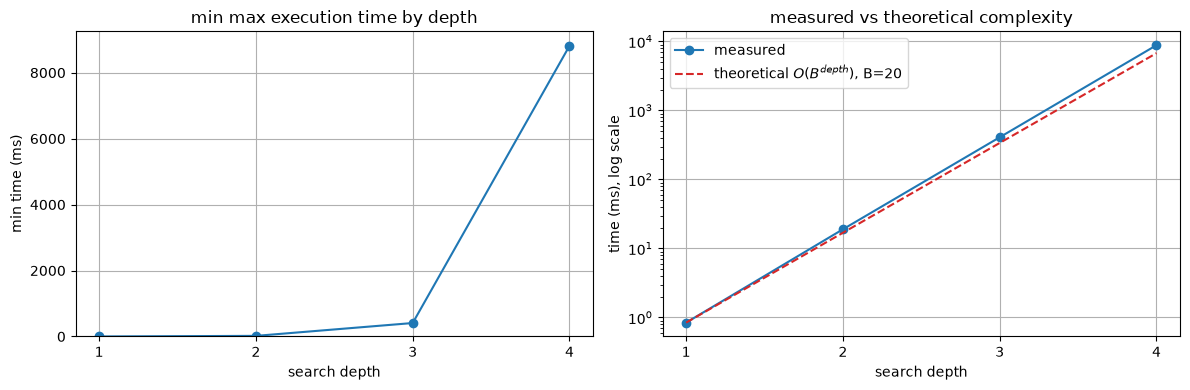

In [4]:
import matplotlib.pyplot as plt

node_cost_ms = times_ms[0] / node_counts[0]
predicted_ms = [node_cost_ms * sum(BRANCHING ** k for k in range(d + 1)) for d in DEPTHS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(DEPTHS, times_ms, marker="o", color="tab:blue")
ax1.set_xlabel("search depth")
ax1.set_ylabel("min time (ms)")
ax1.set_title("min max execution time by depth")
ax1.set_xticks(DEPTHS)
ax1.set_ylim(bottom=0)
ax1.grid(True)

ax2.semilogy(DEPTHS, times_ms, marker="o", color="tab:blue", label="measured")
ax2.semilogy(DEPTHS, predicted_ms, linestyle="--", color="tab:red", label=f"theoretical $O(B^{{depth}})$, B={BRANCHING}")
ax2.set_xlabel("search depth")
ax2.set_ylabel("time (ms), log scale")
ax2.set_title("measured vs theoretical complexity")
ax2.set_xticks(DEPTHS)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reading the results

1. **The growth factor converges to ≈ 20** — the last column of the table approaches the engine's
   branching factor. Each additional depth multiplies the tree by `MAX_CANDIDATE_MOVES`; this is
   `O(B^depth)` complexity, confirmed empirically on the real implementation.
2. **The measured curve sits on the theoretical line** — on the log chart the blue points lie on
   the red dashed prediction computed from the per-node cost alone. The model
   `T(d) = c · Σ B^k` fully explains the measured times.
3. **What one node costs** — roughly a twentieth of a millisecond (≈ 20 000 nodes per second),
   dominated by one full `evaluate` sweep (terminal check + living-set counting) plus one
   candidate generation per visited node.
4. **Projection beyond depth 4** — the model extrapolates directly: depth 5 ≈ 3 minutes,
   depth 6 ≈ 1 hour. This is why the engine's default depth is 3, and why plain min-max is only
   playable at `depth 2`-`4`.
5. **The fix is pruning, not tuning** — alpha-beta pruning explores the same best move but cuts
   the effective branching roughly to `√B ≈ 4.5` with good move ordering, turning depth 6 from
   an hour into seconds. That is the natural next optimization step on top of this naive search.
6. **Search depth is the engine's strength/cost dial** — every extra ply buys lookahead at a
   multiplicative price; the `depth d` command (default 3) exposes exactly this trade-off.